In [1]:
library(reshape2)
library(Seurat)
library(ggplot2)
library(dplyr)
library(scales)
library(corrplot)
library(dittoSeq)
library(SCpubr)
library(tidyverse)
library(RColorBrewer)
library(reticulate)
source("scripts/custom_magma.R")
source("scripts/robust_nmf_programs.R")   

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following object is masked from ‘package:base’:

    intersect



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


corrplot 0.92 loaded





── SCpubr 2.0.0.9000 ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

ℹ Have a look at extensive tutorials in SCpubr's book.

✔ If you use SCpubr in your research, please cite it accordingly.

★ If the package is useful to you, consider leaving a Star in the GitHub repository.

! Keep track of the package updates on Twitter (@Enblacar) or in the Official NEWS website.

♥ Happy plotting!



── Package version ──

CRAN:           2.0.2
Installed: 2.0.0.9000

⚠ There is a new version available onCRAN!




### Smart-seq

In [2]:
smart <- readRDS('/projects/0/einf2548/cruiz/dmg/data/rna_dmg_atlas_smart_seq_datasets.rds')
smart

An object of class Seurat 
19283 features across 11767 samples within 3 assays 
Active assay: RNA (19248 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 2 other assays present: prediction.score.coarse, prediction.score.gbmap.based
 4 dimensional reductions calculated: pca, umap, ref.pca, ref.umap

In [5]:
# subset myeloid cells
smart =subset(smart, idents = c('5','20','24','25'))
smart

An object of class Seurat 
19283 features across 939 samples within 3 assays 
Active assay: RNA (19248 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 2 other assays present: prediction.score.coarse, prediction.score.gbmap.based
 4 dimensional reductions calculated: pca, umap, ref.pca, ref.umap

In [12]:
MP_list = readRDS('data/robust_NMF_programs_myeloid_nomt_noribo.rds')

In [13]:
# Exclude core programs
MP_list <- MP_list[, colnames(MP_list) %in% c("MP_2", "MP_7", "MP_8", "MP_9")]
MP_list

MP_2,MP_7,MP_8,MP_9
ACTG1,CCL3,F13A1,MYO1E
ATP5F1E,CD83,MRC1,GAS7
C1QC,NR4A1,COLEC12,GPNMB
CST3,CCL4,LYVE1,LPL
FAU,NR4A2,CD163,ASAP1
PTMA,CCL4L2,DAPK1,GLDN
CD63,EGR3,SELENOP,HIVEP1
FTL,IRAK2,THRB,MITF
S100A11,NFKBID,CD163L1,PTPRG
CD81,CCL3L1,MCTP1,RGCC


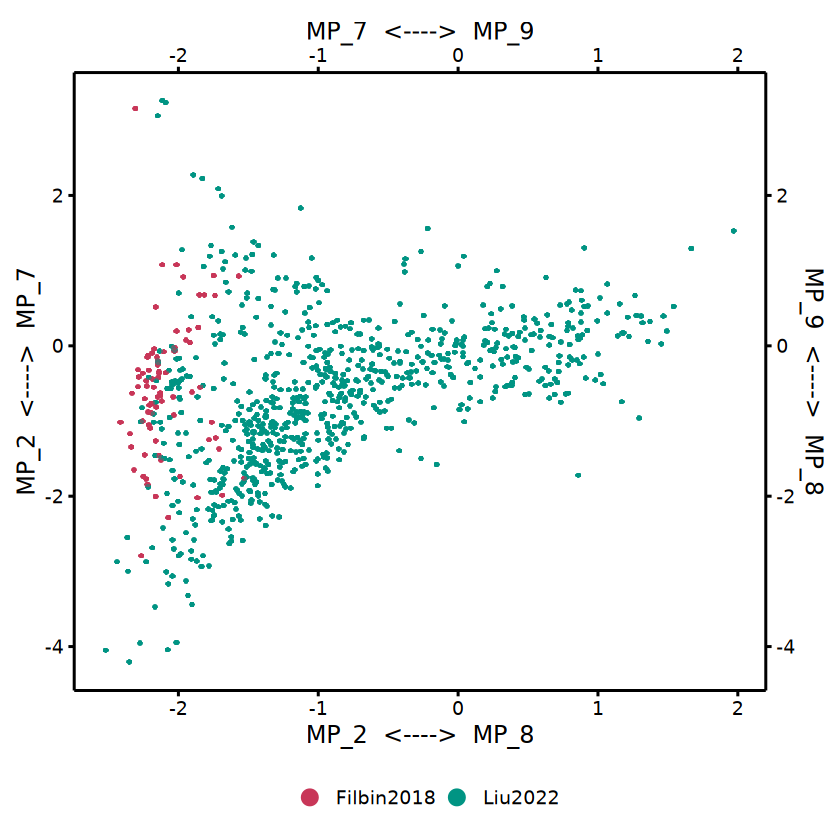

In [15]:
do_CellularStatesPlot(sample = smart,
                      group.by = 'Study',
                      pt.size = 5,
                      plot_cell_borders = FALSE,
                      raster = TRUE,
                      # plot_marginal_distributions = TRUE,
                                   input_gene_list = as.list(as.data.frame(MP_list)),
                                   x1 = "MP_7",
                                   y1 = "MP_2",
                                   x2 = "MP_9",
                                   y2 = "MP_8",
                                   enforce_symmetry = FALSE)

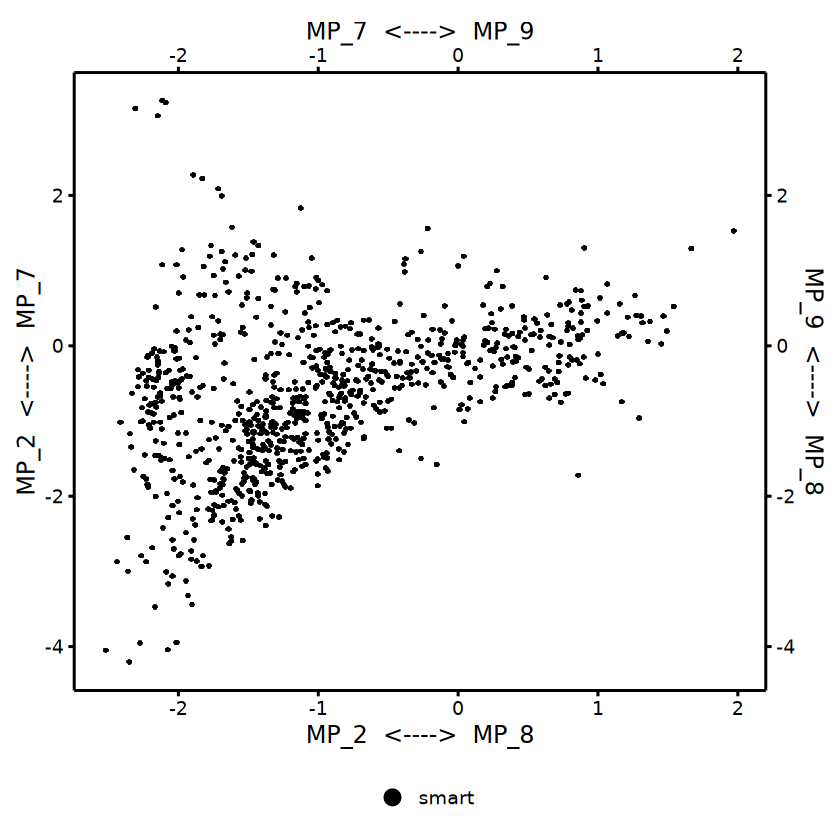

In [16]:
smart$tech <- 'smart'
do_CellularStatesPlot(sample = smart,
                      colors.use = c('smart'= 'black'),
                      group.by = 'tech',
                      pt.size = 5,
                      plot_cell_borders = FALSE,
                      raster = TRUE,
                      # plot_marginal_distributions = TRUE,
                                   input_gene_list = as.list(as.data.frame(MP_list)),
                                   x1 = "MP_7",
                                   y1 = "MP_2",
                                   x2 = "MP_9",
                                   y2 = "MP_8",
                                   enforce_symmetry = FALSE)

In [17]:
ggsave('figures/state_plot_myeloid_cells_smart.pdf')

Saving 6.67 x 6.67 in image


In [18]:
for (i in 1:ncol(MP_list)) {
  gene_set <- as.data.frame(MP_list)[[i]]
  smart <- AddModuleScore(
    object = smart,
    features = list(gene_set),
    name = paste0(colnames(MP_list)[i], '_')
  )
}

Warning message:
“The following features are not present in the object: C12ORF57, not searching for symbol synonyms”


In [21]:
# Extracting the scores
scores <- FetchData(
  smart,
  vars = c('MP_2_1', 'MP_7_1','MP_8_1','MP_9_1')
)

colnames(scores) <- sub("_1$", "", colnames(scores))
colnames(scores) <- sub("_", "", colnames(scores))

scores

,MP2,MP7,MP8,MP9
,<dbl>,<dbl>,<dbl>,<dbl>
BCH836-P01-B05,2.985916,1.5300628,-0.7343706,0.65837014
BCH836-P01-B12,3.033663,1.1868535,-0.6237198,0.46964339
BCH836-P01-C06,3.263602,2.9193093,-0.1394725,0.31560676
BCH836-P01-C09,3.008187,2.1072306,-0.5528620,0.42661102
BCH836-P01-C10,2.721617,3.3969894,-0.5519716,0.88156225
BCH836-P01-C12,1.495004,-0.2763464,-0.3959780,-0.81681399
BCH836-P01-D12,2.631879,1.9469266,-0.4710378,-0.01844099
BCH836-P01-G01,3.151646,3.2240176,-0.5930377,0.36942762
BCH836-P01-H02,2.696683,2.4925252,-0.7346866,1.21103540


In [22]:
# as suggested in https://doi.org/10.1038/s41588-023-01570-0
# Normalize scores by subtracting the mean score for each MP
normalized_scores <- apply(scores, 2, function(x) x - mean(x))
                           
# Function to determine the assignment of each cell
assign_to_MP <- function(score_row) {
  sorted_scores <- sort(score_row, decreasing = TRUE)
  top_score <- sorted_scores[1]
  second_score <- sorted_scores[2]

  if (second_score <= 0.95 * top_score) {
    return(names(sorted_scores)[1])
  } else {
    return("unresolved")
  }
}

# Apply the function to each row (cell)
cell_assignments <- apply(normalized_scores, 1, assign_to_MP)

In [23]:
smart$MP_Assignment <- cell_assignments

Warning message:
“Scaling data with a low number of groups may produce misleading results”
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


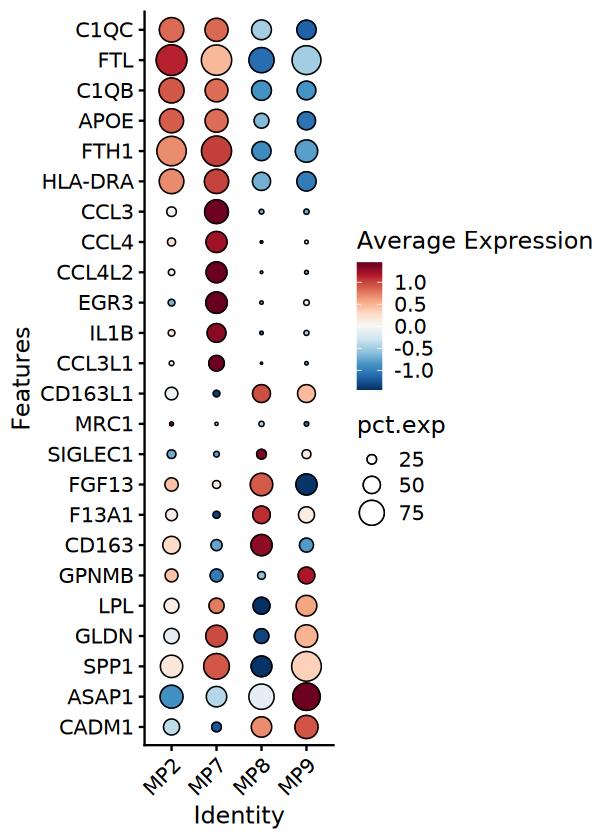

In [31]:
smart$MP_Assignment <- factor(smart$MP_Assignment,
                             levels=c('MP2', 'MP7',
                                          'MP8','MP9','unresolved'))
options(repr.plot.height = 7, repr.plot.width = 5)
DotPlot(subset(smart, MP_Assignment!='unresolved'),dot.scale = 8,
        features = rev(c('C1QC','FTL','C1QB', 'APOE','FTH1','HLA-DRA',
                                     'CCL3', 'CCL4', 'CCL4L2','EGR3','IL1B', 'CCL3L1',
                                     'CD163L1', 'MRC1', 'SIGLEC1', 'FGF13','F13A1', 'CD163',
                                     'GPNMB', 'LPL', 'GLDN', 'SPP1','ASAP1','CADM1')), 
        group.by = 'MP_Assignment', assay = 'RNA') +
  geom_point(aes(size=pct.exp), shape = 21, colour="black", stroke=0.5) +
  scale_color_gradientn(colors =rev(RColorBrewer::brewer.pal(11, "RdBu"))) + 
  guides(size=guide_legend(override.aes=list(shape=21, colour="black", fill="white")))+
  theme(axis.text.x = element_text(angle = 45, hjust = 1))+coord_flip()

In [32]:
ggsave('figures/dotplot_MP_genes_smart_seq.pdf', width = 4.5)

Saving 4.5 x 6.67 in image


Warning message:
“Scaling data with a low number of groups may produce misleading results”
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


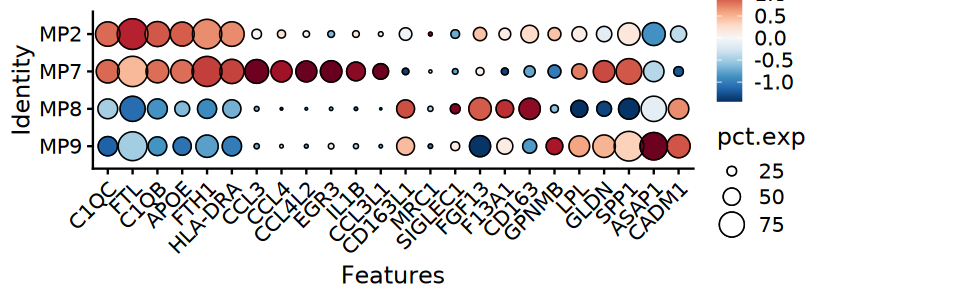

In [46]:
smart$MP_Assignment <- factor(smart$MP_Assignment,
                             levels=rev(c('MP2', 'MP7',
                                          'MP8','MP9','unresolved')))
options(repr.plot.height = 2.5, repr.plot.width = 8)
DotPlot(subset(smart, MP_Assignment!='unresolved'),dot.scale = 8,
        features = c('C1QC','FTL','C1QB', 'APOE','FTH1','HLA-DRA',
                                     'CCL3', 'CCL4', 'CCL4L2','EGR3','IL1B', 'CCL3L1',
                                     'CD163L1', 'MRC1', 'SIGLEC1', 'FGF13','F13A1', 'CD163',
                                     'GPNMB', 'LPL', 'GLDN', 'SPP1','ASAP1','CADM1'), 
        group.by = 'MP_Assignment', assay = 'RNA') +
  geom_point(aes(size=pct.exp), shape = 21, colour="black", stroke=0.5) +
  scale_color_gradientn(colors =rev(RColorBrewer::brewer.pal(11, "RdBu"))) + 
  guides(size=guide_legend(override.aes=list(shape=21, colour="black", fill="white")))+
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

In [48]:
ggsave('figures/dotplot_MP_genes_smart_seq.pdf', height = 2.5, width = 9)

### DeSisto

In [2]:
desisto <- readRDS('/projects/0/einf2548/cruiz/dmg/data/DeSisto_qc_filtered_and_normalized.rds')
desisto

An object of class Seurat 
16193 features across 6979 samples within 1 assay 
Active assay: RNA (16193 features, 0 variable features)
 1 layer present: data
 2 dimensional reductions calculated: pca, umap

In [5]:
# subset myeloid cells
desisto =subset(desisto, idents = c('10','3','18','20'))
desisto

An object of class Seurat 
16193 features across 1017 samples within 1 assay 
Active assay: RNA (16193 features, 2000 variable features)
 2 layers present: data, scale.data
 2 dimensional reductions calculated: pca, umap

In [8]:
MP_list = readRDS('data/robust_NMF_programs_myeloid_nomt_noribo.rds')

In [9]:
# Exclude core programs
MP_list <- MP_list[, colnames(MP_list) %in% c("MP_2", "MP_7", "MP_8", "MP_9")]
MP_list

MP_2,MP_7,MP_8,MP_9
ACTG1,CCL3,F13A1,MYO1E
ATP5F1E,CD83,MRC1,GAS7
C1QC,NR4A1,COLEC12,GPNMB
CST3,CCL4,LYVE1,LPL
FAU,NR4A2,CD163,ASAP1
PTMA,CCL4L2,DAPK1,GLDN
CD63,EGR3,SELENOP,HIVEP1
FTL,IRAK2,THRB,MITF
S100A11,NFKBID,CD163L1,PTPRG
CD81,CCL3L1,MCTP1,RGCC


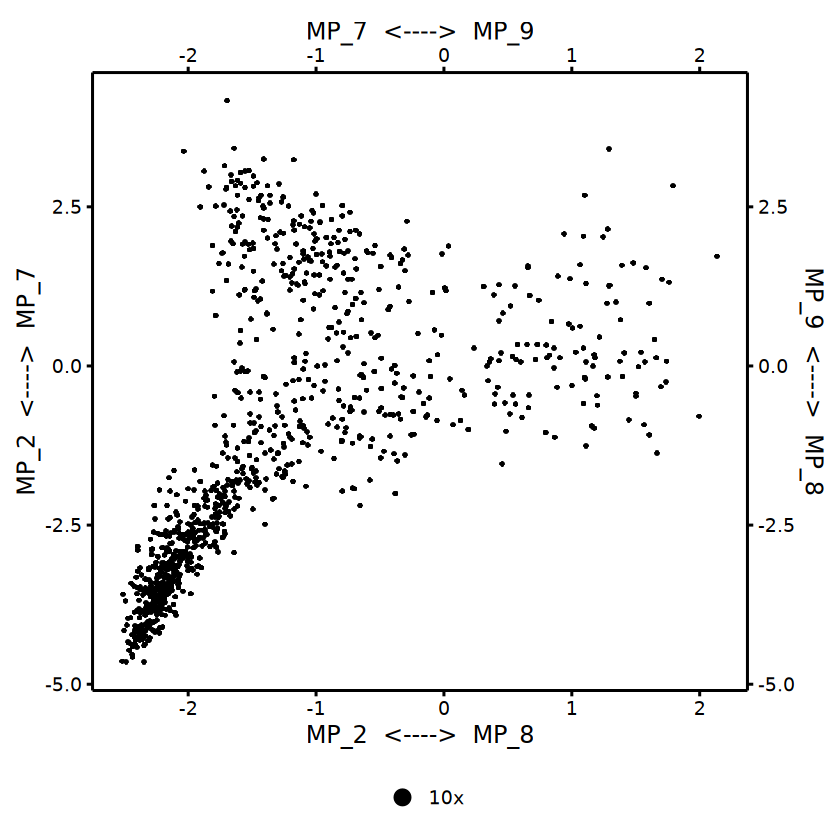

In [11]:
desisto$tech <- '10x'
do_CellularStatesPlot(sample = desisto,
                      colors.use = c('10x'= 'black'),
                      group.by = 'tech',
                      pt.size = 5,
                      plot_cell_borders = FALSE,
                      raster = TRUE,
                      # plot_marginal_distributions = TRUE,
                                   input_gene_list = as.list(as.data.frame(MP_list)),
                                   x1 = "MP_7",
                                   y1 = "MP_2",
                                   x2 = "MP_9",
                                   y2 = "MP_8",
                                   enforce_symmetry = FALSE)

In [12]:
ggsave('figures/state_plot_myeloid_cells_desisto.pdf')

Saving 6.67 x 6.67 in image


In [13]:
for (i in 1:ncol(MP_list)) {
  gene_set <- as.data.frame(MP_list)[[i]]
  desisto <- AddModuleScore(
    object = desisto,
    features = list(gene_set),
    name = paste0(colnames(MP_list)[i], '_')
  )
}

Warning message:
“The following features are not present in the object: C12ORF57, not searching for symbol synonyms”


In [16]:
# Extracting the scores
scores <- FetchData(
  desisto,
  vars = c('MP_2_1', 'MP_7_1','MP_8_1','MP_9_1')
)

colnames(scores) <- sub("_1$", "", colnames(scores))
colnames(scores) <- sub("_", "", colnames(scores))

scores

,MP2,MP7,MP8,MP9
,<dbl>,<dbl>,<dbl>,<dbl>
DMG_1_TGTCCTGGTACTGCCG-1,3.891002,-0.144676974,0.093606727,0.11199440
DMG_1_CGTTAGATCTCGAGTA-1,3.857183,-0.752289801,0.182301743,-0.34090095
DMG_1_CGGCAGTAGATGGTAT-1,3.424301,0.004541003,0.022164035,-0.18243445
DMG_1_TCGGGTGTCTATTTCG-1,3.778777,-0.625637151,0.045085092,-0.39061041
DMG_1_CAACGGCTCGTCAGAT-1,4.308597,-0.123497591,0.074730251,0.20291820
DMG_1_ACTGCAAGTGGACTGA-1,3.852370,-0.525586343,0.118457889,-0.03693253
DMG_1_CCTCTCCGTAAGTTGA-1,3.164334,-1.214481221,-0.053517480,-0.32692991
DMG_1_GAAGGACTCATTCGGA-1,4.002472,-0.401853751,0.054375323,-0.30975323
DMG_1_TGGGTTAAGCCTCCAG-1,4.015528,-0.110236579,0.342031383,-0.17740568


In [17]:
# as suggested in https://doi.org/10.1038/s41588-023-01570-0
# Normalize scores by subtracting the mean score for each MP
normalized_scores <- apply(scores, 2, function(x) x - mean(x))
                           
# Function to determine the assignment of each cell
assign_to_MP <- function(score_row) {
  sorted_scores <- sort(score_row, decreasing = TRUE)
  top_score <- sorted_scores[1]
  second_score <- sorted_scores[2]

  if (second_score <= 0.95 * top_score) {
    return(names(sorted_scores)[1])
  } else {
    return("unresolved")
  }
}

# Apply the function to each row (cell)
cell_assignments <- apply(normalized_scores, 1, assign_to_MP)

In [18]:
desisto$MP_Assignment <- cell_assignments

Warning message:
“Scaling data with a low number of groups may produce misleading results”
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


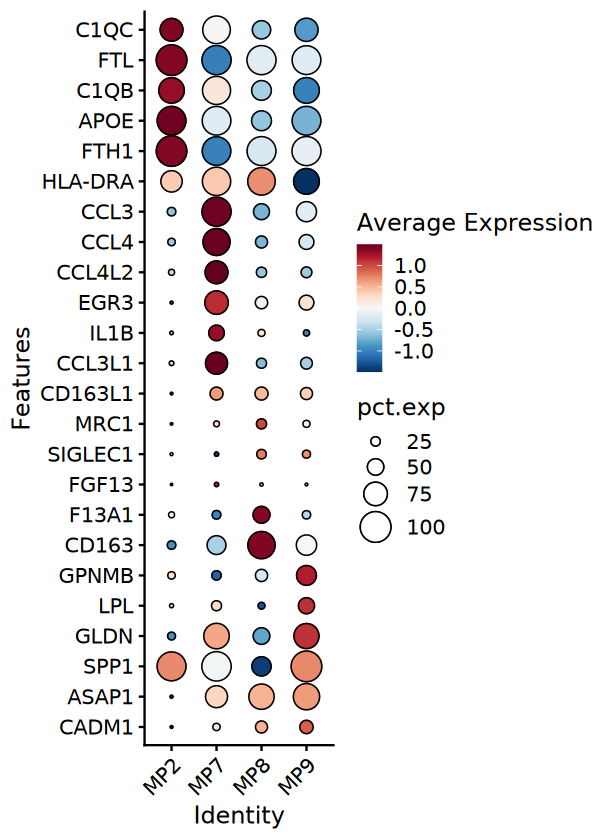

In [37]:
desisto$MP_Assignment <- factor(desisto$MP_Assignment,
                             levels=c('MP2', 'MP7',
                                          'MP8','MP9','unresolved'))
options(repr.plot.height = 7, repr.plot.width = 5)
DotPlot(subset(desisto, MP_Assignment!='unresolved'),dot.scale = 8,
        features = rev(c('C1QC','FTL','C1QB', 'APOE','FTH1','HLA-DRA',
                                     'CCL3', 'CCL4', 'CCL4L2','EGR3','IL1B', 'CCL3L1',
                                     'CD163L1', 'MRC1', 'SIGLEC1', 'FGF13','F13A1', 'CD163',
                                     'GPNMB', 'LPL', 'GLDN', 'SPP1','ASAP1','CADM1')), 
        group.by = 'MP_Assignment', assay = 'RNA') +
  geom_point(aes(size=pct.exp), shape = 21, colour="black", stroke=0.5) +
  scale_color_gradientn(colors =rev(RColorBrewer::brewer.pal(11, "RdBu"))) + 
  guides(size=guide_legend(override.aes=list(shape=21, colour="black", fill="white")))+
  theme(axis.text.x = element_text(angle = 45, hjust = 1))+coord_flip()

In [39]:
ggsave('figures/dotplot_MP_genes_sisto.pdf', width = 4.5)

Saving 4.5 x 6.67 in image


Warning message:
“Scaling data with a low number of groups may produce misleading results”
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


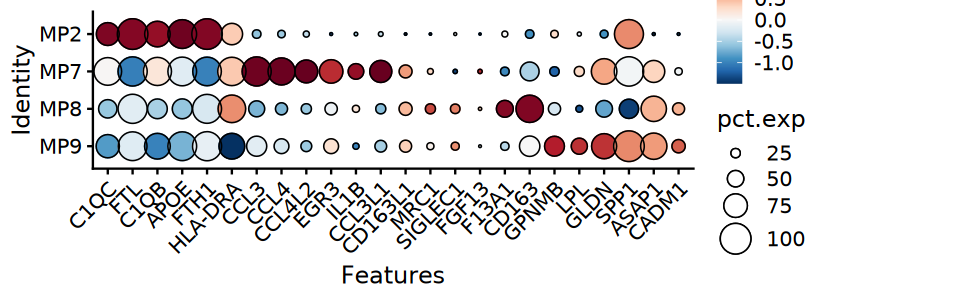

In [29]:
desisto$MP_Assignment <- factor(desisto$MP_Assignment,
                             levels=rev(c('MP2', 'MP7',
                                          'MP8','MP9','unresolved')))
options(repr.plot.height = 2.5, repr.plot.width = 8)
DotPlot(subset(desisto, MP_Assignment!='unresolved'),dot.scale = 8,
        features = c('C1QC','FTL','C1QB', 'APOE','FTH1','HLA-DRA',
                                     'CCL3', 'CCL4', 'CCL4L2','EGR3','IL1B', 'CCL3L1',
                                     'CD163L1', 'MRC1', 'SIGLEC1', 'FGF13','F13A1', 'CD163',
                                     'GPNMB', 'LPL', 'GLDN', 'SPP1','ASAP1','CADM1'), 
        group.by = 'MP_Assignment', assay = 'RNA') +
  geom_point(aes(size=pct.exp), shape = 21, colour="black", stroke=0.5) +
  scale_color_gradientn(colors =rev(RColorBrewer::brewer.pal(11, "RdBu"))) + 
  guides(size=guide_legend(override.aes=list(shape=21, colour="black", fill="white")))+
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

In [30]:
ggsave('figures/dotplot_MP_genes_sisto.pdf', height = 2.5, width = 9)

### Sussman

In [2]:
sussman2024_myeloid <- readRDS('/projects/0/einf2548/cruiz/dmg/public_data/Sussman2024/Final_Cohort_All_snRNA-seq_H3K27_H3WT_myeloid.RDS')
sussman2024_myeloid

An object of class Seurat 
19508 features across 18105 samples within 14 assays 
Active assay: RNA (19152 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 13 other assays present: prediction.score.dmg.atlas.lvl_1, prediction.score.dmg.atlas.lvl_2, prediction.score.dmg.atlas.lvl_3, prediction.score.dmg.atlas.lvl_4, prediction.score.dmg.atlas.lvl_4_coarse, prediction.score.dmg.atlas.lvl_5, prediction.score.dmg.atlas.seuratv4.lvl_1, prediction.score.dmg.atlas.seuratv4.lvl_2, prediction.score.dmg.atlas.seuratv4.lvl_3, prediction.score.dmg.atlas.seuratv4.lvl_4, prediction.score.dmg.atlas.seuratv4.lvl_4_coarse, prediction.score.dmg.atlas.seuratv4.lvl_5, prediction.score.atlas
 4 dimensional reductions calculated: pca, umap, ref.pca, ref.umap

In [3]:
MP_list = readRDS('data/robust_NMF_programs_myeloid_nomt_noribo.rds')

In [4]:
# Exclude core programs
MP_list <- MP_list[, colnames(MP_list) %in% c("MP_2", "MP_7", "MP_8", "MP_9")]
MP_list

MP_2,MP_7,MP_8,MP_9
ACTG1,CCL3,F13A1,MYO1E
ATP5F1E,CD83,MRC1,GAS7
C1QC,NR4A1,COLEC12,GPNMB
CST3,CCL4,LYVE1,LPL
FAU,NR4A2,CD163,ASAP1
PTMA,CCL4L2,DAPK1,GLDN
CD63,EGR3,SELENOP,HIVEP1
FTL,IRAK2,THRB,MITF
S100A11,NFKBID,CD163L1,PTPRG
CD81,CCL3L1,MCTP1,RGCC


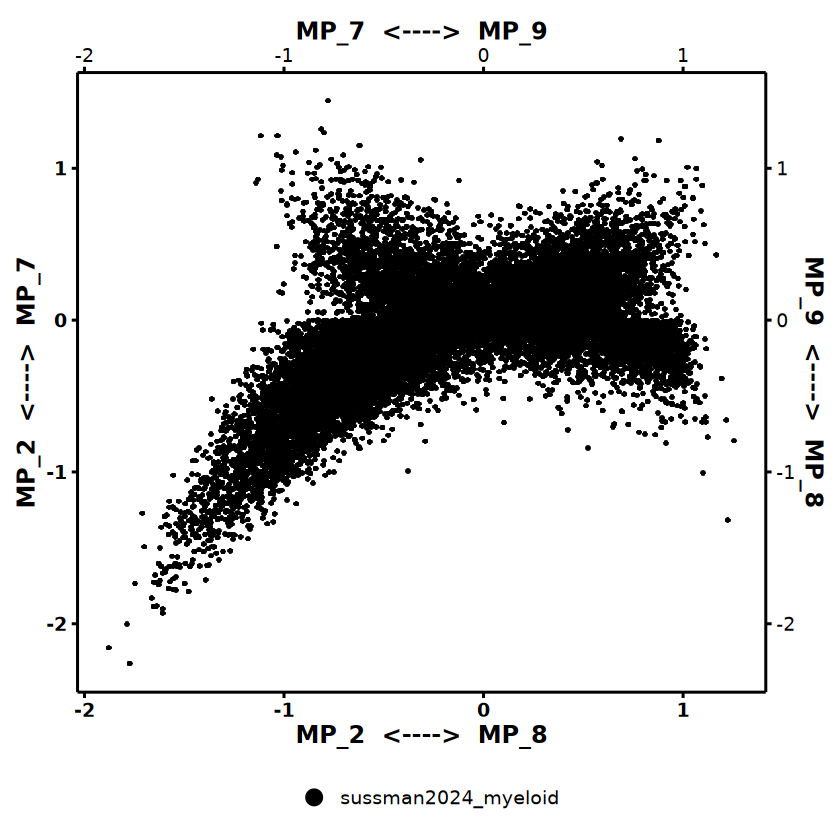

In [7]:
sussman2024_myeloid$tech <- 'sussman2024_myeloid'
do_CellularStatesPlot(sample = sussman2024_myeloid,
                      colors.use = c('sussman2024_myeloid'= 'black'),
                      group.by = 'tech',
                      pt.size = 5,
                      plot_cell_borders = FALSE,
                      raster = TRUE,
                      # plot_marginal_distributions = TRUE,
                                   input_gene_list = as.list(as.data.frame(MP_list)),
                                   x1 = "MP_7",
                                   y1 = "MP_2",
                                   x2 = "MP_9",
                                   y2 = "MP_8",
                                   enforce_symmetry = FALSE)

In [8]:
ggsave('figures/state_plot_myeloid_cells_sussman2024_myeloid.pdf')

Saving 6.67 x 6.67 in image


In [9]:
for (i in 1:ncol(MP_list)) {
  gene_set <- as.data.frame(MP_list)[[i]]
  sussman2024_myeloid <- AddModuleScore(
    object = sussman2024_myeloid,
    features = list(gene_set),
    name = paste0(colnames(MP_list)[i], '_')
  )
}

Warning message:
“The following features are not present in the object: C12ORF57, H3F3B, not searching for symbol synonyms”


In [10]:
# Extracting the scores
scores <- FetchData(
  sussman2024_myeloid,
  vars = c('MP_2_1', 'MP_7_1','MP_8_1','MP_9_1')
)

colnames(scores) <- sub("_1$", "", colnames(scores))
colnames(scores) <- sub("_", "", colnames(scores))

scores

,MP2,MP7,MP8,MP9
,<dbl>,<dbl>,<dbl>,<dbl>
AAAGGGCTCGGAGCAA-1_1,0.304317253,-0.126125852,-0.18445866,-0.0005404564
AAAGTGAGTGAGCCAA-1_1,0.094710703,-0.008085808,-0.15371171,0.0997995232
AACGGGAAGAAATCCA-1_1,0.021324252,0.107239668,-0.15674737,0.4681775278
AATGACCGTGTACATC-1_1,0.522782248,-0.125328559,-0.23725685,0.0973657302
ACTATCTAGCTAAATG-1_1,-0.172820105,-0.294516981,-0.31627491,0.0652659423
ACTGATGCAAACTCTG-1_1,0.410989010,-0.154747737,-0.19692301,0.1860539396
AGACAGGTCGACTCCT-1_1,-0.060139646,-0.413898201,-0.03818618,-0.2103080463
AGCCAGCCACTTGGGC-1_1,0.262891471,-0.283347201,0.23073852,-0.2887432893
ATACCTTAGGTTCCGC-1_1,-0.062757364,-0.114755104,-0.19252602,-0.0178383914


In [11]:
# as suggested in https://doi.org/10.1038/s41588-023-01570-0
# Normalize scores by subtracting the mean score for each MP
normalized_scores <- apply(scores, 2, function(x) x - mean(x))
                           
# Function to determine the assignment of each cell
assign_to_MP <- function(score_row) {
  sorted_scores <- sort(score_row, decreasing = TRUE)
  top_score <- sorted_scores[1]
  second_score <- sorted_scores[2]

  if (second_score <= 0.95 * top_score) {
    return(names(sorted_scores)[1])
  } else {
    return("unresolved")
  }
}

# Apply the function to each row (cell)
cell_assignments <- apply(normalized_scores, 1, assign_to_MP)

In [12]:
sussman2024_myeloid$MP_Assignment <- cell_assignments

Warning message:
“Scaling data with a low number of groups may produce misleading results”
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


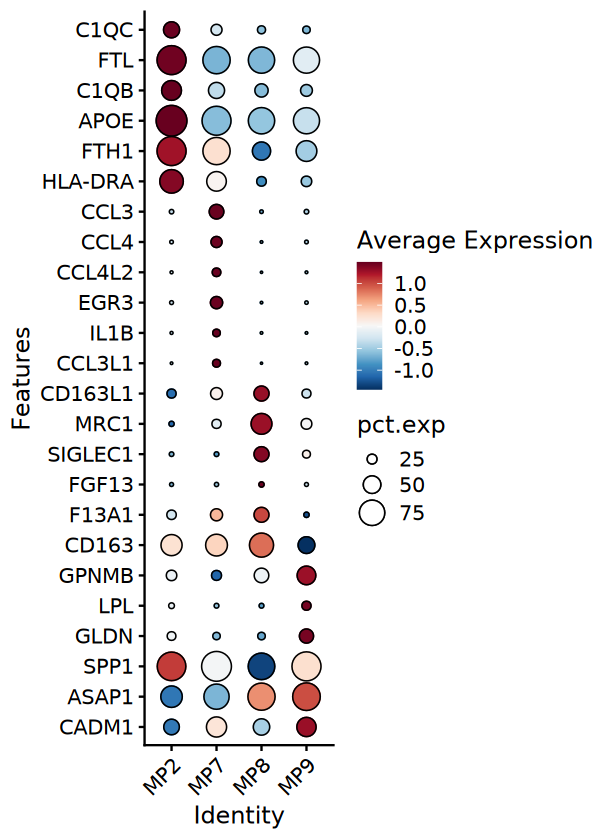

In [13]:
sussman2024_myeloid$MP_Assignment <- factor(sussman2024_myeloid$MP_Assignment,
                             levels=c('MP2', 'MP7',
                                          'MP8','MP9','unresolved'))
options(repr.plot.height = 7, repr.plot.width = 5)
DotPlot(subset(sussman2024_myeloid, MP_Assignment!='unresolved'),dot.scale = 8,
        features = rev(c('C1QC','FTL','C1QB', 'APOE','FTH1','HLA-DRA',
                                     'CCL3', 'CCL4', 'CCL4L2','EGR3','IL1B', 'CCL3L1',
                                     'CD163L1', 'MRC1', 'SIGLEC1', 'FGF13','F13A1', 'CD163',
                                     'GPNMB', 'LPL', 'GLDN', 'SPP1','ASAP1','CADM1')), 
        group.by = 'MP_Assignment', assay = 'RNA') +
  geom_point(aes(size=pct.exp), shape = 21, colour="black", stroke=0.5) +
  scale_color_gradientn(colors =rev(RColorBrewer::brewer.pal(11, "RdBu"))) + 
  guides(size=guide_legend(override.aes=list(shape=21, colour="black", fill="white")))+
  theme(axis.text.x = element_text(angle = 45, hjust = 1))+coord_flip()

In [14]:
ggsave('figures/dotplot_MP_genes_sussman2024_myeloid_seq.pdf', width = 4.5)

Saving 4.5 x 6.67 in image


### LaBelle smart

In [18]:
# Load expression matrix
expr <- read.table("/projects/0/einf2548/cruiz/dmg/public_data/LaBelle2025/GSE227983_immune_ss2_tpm.txt.gz", header = TRUE, row.names = 1, sep = "\t", check.names = FALSE)

# Load metadata
meta <- read.table("/projects/0/einf2548/cruiz/dmg/public_data/LaBelle2025/GSE227983_immune_ss2_meta.txt.gz", header = TRUE, row.names = 1, sep = "\t")

In [22]:
# Ensure the columns of expression match the rows of metadata
expr <- expr[, rownames(meta)]

# Create Seurat object
labelle <- CreateSeuratObject(counts = expr, meta.data = meta)

# Optional: log-transform TPM values if needed (TPM are not raw counts)
labelle <- NormalizeData(labelle, normalization.method = "LogNormalize", scale.factor = 10000) %>% FindVariableFeatures() %>% ScaleData()

# Check the object
labelle

Warning message:
“Data is of class data.frame. Coercing to dgCMatrix.”
Normalizing layer: counts

Finding variable features for layer counts

Centering and scaling data matrix



An object of class Seurat 
19357 features across 4158 samples within 1 assay 
Active assay: RNA (19357 features, 2000 variable features)
 3 layers present: counts, data, scale.data

In [25]:
# Define the Subtype values you're interested in
subtype_values <- c("Hemispheric-HistoneWT", "Midline-H3K27M", "Midline-HistoneWT")

# Subset the Seurat object
labelle <- subset(
  labelle,
  subset = Subtype %in% subtype_values & detailed_annot == "Myeloid"
)
labelle

Warning message:
“Removing 171 cells missing data for vars requested”


An object of class Seurat 
19357 features across 676 samples within 1 assay 
Active assay: RNA (19357 features, 2000 variable features)
 3 layers present: counts, data, scale.data

In [26]:
MP_list = readRDS('data/robust_NMF_programs_myeloid_nomt_noribo.rds')

In [27]:
# Exclude core programs
MP_list <- MP_list[, colnames(MP_list) %in% c("MP_2", "MP_7", "MP_8", "MP_9")]
MP_list

MP_2,MP_7,MP_8,MP_9
ACTG1,CCL3,F13A1,MYO1E
ATP5F1E,CD83,MRC1,GAS7
C1QC,NR4A1,COLEC12,GPNMB
CST3,CCL4,LYVE1,LPL
FAU,NR4A2,CD163,ASAP1
PTMA,CCL4L2,DAPK1,GLDN
CD63,EGR3,SELENOP,HIVEP1
FTL,IRAK2,THRB,MITF
S100A11,NFKBID,CD163L1,PTPRG
CD81,CCL3L1,MCTP1,RGCC


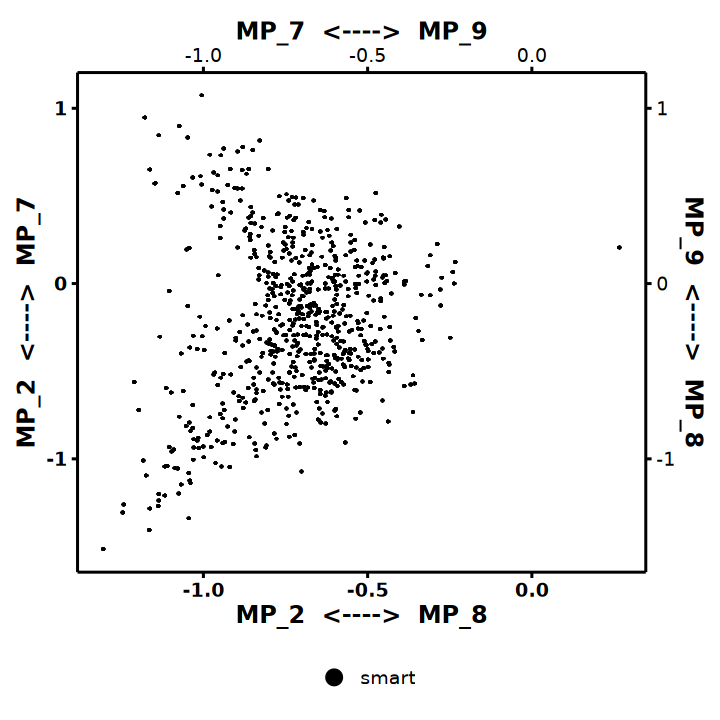

In [31]:
labelle$tech <- 'smart'
do_CellularStatesPlot(sample = labelle,
                      colors.use = c('smart'= 'black'),
                      group.by = 'tech',
                      pt.size = 5,
                      plot_cell_borders = FALSE,
                      raster = TRUE,
                      # plot_marginal_distributions = TRUE,
                                   input_gene_list = as.list(as.data.frame(MP_list)),
                                   x1 = "MP_7",
                                   y1 = "MP_2",
                                   x2 = "MP_9",
                                   y2 = "MP_8",
                                   enforce_symmetry = FALSE)

In [32]:
ggsave('figures/state_plot_myeloid_cells_labelle.pdf')

Saving 6.67 x 6.67 in image


In [33]:
for (i in 1:ncol(MP_list)) {
  gene_set <- as.data.frame(MP_list)[[i]]
  labelle <- AddModuleScore(
    object = labelle,
    features = list(gene_set),
    name = paste0(colnames(MP_list)[i], '_')
  )
}

Warning message:
“The following features are not present in the object: ATP5F1E, RACK1, not searching for symbol synonyms”
Warning message:
“The following features are not present in the object: C12ORF57, not searching for symbol synonyms”
Warning message:
“The following features are not present in the object: SELENOP, MS4A4E, not searching for symbol synonyms”
Warning message:
“The following features are not present in the object: MTRNR2L12, not searching for symbol synonyms”


In [34]:
# Extracting the scores
scores <- FetchData(
  labelle,
  vars = c('MP_2_1', 'MP_7_1','MP_8_1','MP_9_1')
)

colnames(scores) <- sub("_1$", "", colnames(scores))
colnames(scores) <- sub("_", "", colnames(scores))

scores

,MP2,MP7,MP8,MP9
,<dbl>,<dbl>,<dbl>,<dbl>
BT1416CD3_P1_A01,0.5690111,0.39159600,-0.13561335,-0.094411070
BT1416CD45_P1_A02,0.5308630,0.02869937,0.01877102,-0.059386601
BT1416CD45_P1_A03,0.6304014,0.60172428,0.09593790,-0.110101523
BT1416CD45_P1_A04,0.8357003,-0.43072005,0.08652473,-0.091835014
BT1416CD45_P1_A05,0.7775600,0.56468583,-0.11467325,-0.087784442
BT1416CD45_P1_A06,0.6692451,0.52206557,0.01404521,0.319611560
BT1416CD45_P1_A07,0.9215031,-0.25365793,0.04405181,0.004754326
BT1416CD45_P1_A08,0.5656853,0.08070733,-0.14339660,0.190118287
BT1416CD45_P1_A09,0.6672044,0.48160584,-0.09926128,0.010459584


In [35]:
# as suggested in https://doi.org/10.1038/s41588-023-01570-0
# Normalize scores by subtracting the mean score for each MP
normalized_scores <- apply(scores, 2, function(x) x - mean(x))
                           
# Function to determine the assignment of each cell
assign_to_MP <- function(score_row) {
  sorted_scores <- sort(score_row, decreasing = TRUE)
  top_score <- sorted_scores[1]
  second_score <- sorted_scores[2]

  if (second_score <= 0.95 * top_score) {
    return(names(sorted_scores)[1])
  } else {
    return("unresolved")
  }
}

# Apply the function to each row (cell)
cell_assignments <- apply(normalized_scores, 1, assign_to_MP)

In [36]:
labelle$MP_Assignment <- cell_assignments

Warning message:
“Scaling data with a low number of groups may produce misleading results”
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


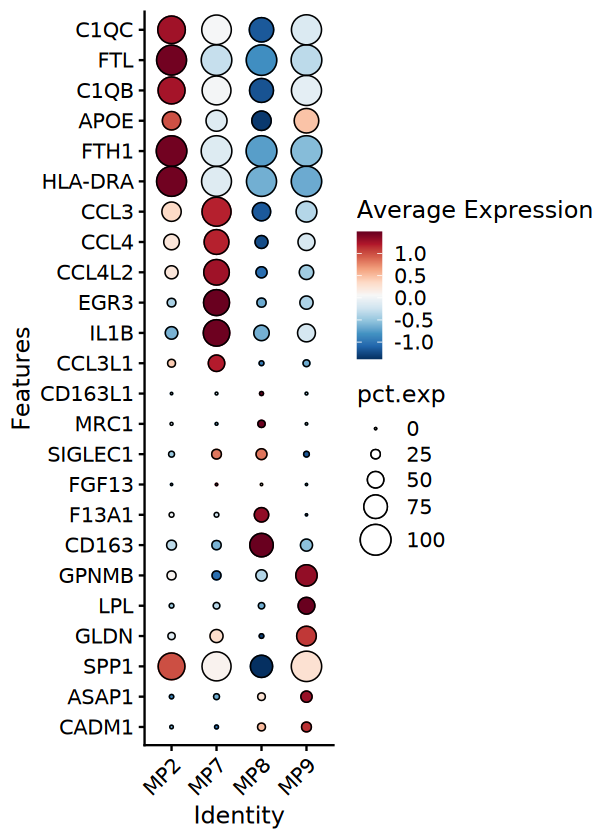

In [37]:
labelle$MP_Assignment <- factor(labelle$MP_Assignment,
                             levels=c('MP2', 'MP7',
                                          'MP8','MP9','unresolved'))
options(repr.plot.height = 7, repr.plot.width = 5)
DotPlot(subset(labelle, MP_Assignment!='unresolved'),dot.scale = 8,
        features = rev(c('C1QC','FTL','C1QB', 'APOE','FTH1','HLA-DRA',
                                     'CCL3', 'CCL4', 'CCL4L2','EGR3','IL1B', 'CCL3L1',
                                     'CD163L1', 'MRC1', 'SIGLEC1', 'FGF13','F13A1', 'CD163',
                                     'GPNMB', 'LPL', 'GLDN', 'SPP1','ASAP1','CADM1')), 
        group.by = 'MP_Assignment', assay = 'RNA') +
  geom_point(aes(size=pct.exp), shape = 21, colour="black", stroke=0.5) +
  scale_color_gradientn(colors =rev(RColorBrewer::brewer.pal(11, "RdBu"))) + 
  guides(size=guide_legend(override.aes=list(shape=21, colour="black", fill="white")))+
  theme(axis.text.x = element_text(angle = 45, hjust = 1))+coord_flip()

In [38]:
ggsave('figures/dotplot_MP_genes_labelle.pdf', width = 4.5)

Saving 4.5 x 6.67 in image


### LaBelle 10x

In [2]:
# Load expression matrix
expr <- read.table("/projects/0/einf2548/cruiz/dmg/public_data/LaBelle2025/GSE227983_immune_tenx_tpm.txt.gz", header = TRUE, row.names = 1, sep = "\t", check.names = FALSE)

# Load metadata
meta <- read.table("/projects/0/einf2548/cruiz/dmg/public_data/LaBelle2025/GSE227983_immune_tenx_meta.txt.gz", header = TRUE, row.names = 1, sep = "\t")

In [3]:
# Create Seurat object
labelle <- CreateSeuratObject(counts = expr, meta.data = meta)

# Optional: log-transform TPM values if needed (TPM are not raw counts)
labelle <- NormalizeData(labelle, normalization.method = "LogNormalize", scale.factor = 10000) %>% FindVariableFeatures() %>% ScaleData()

# Check the object
labelle

Warning message:
“Data is of class data.frame. Coercing to dgCMatrix.”
Normalizing layer: counts

Finding variable features for layer counts

Centering and scaling data matrix



An object of class Seurat 
19357 features across 25050 samples within 1 assay 
Active assay: RNA (19357 features, 2000 variable features)
 3 layers present: counts, data, scale.data

In [10]:
table(meta$Treatment)


      ITN       PD1 Untreated 
    12736     11547       767 

In [11]:
summary_df <- meta %>%
  group_by(sample) %>%
  summarise(Subtype_list = paste(unique(Treatment), collapse = ", "))
summary_df

sample,Subtype_list
<chr>,<chr>
BT1857,ITN
BT1857_TenX,Untreated
BT2062,PD1
BT2080_TenX,PD1
BT2082,ITN
BT2083,ITN


In [12]:
summary_df <- meta %>%
  group_by(Subtype) %>%
  summarise(Subtype_list = paste(unique(Treatment), collapse = ", "))
summary_df

Subtype,Subtype_list
<chr>,<chr>
BT1857_TenX,Untreated
BT2062,PD1
BT2080_TenX,PD1
BT2082,ITN
BT2083,ITN
Hemispheric-HistoneWT,ITN


In [13]:
# Subset the Seurat object
labelle <- subset(
  labelle,
  subset = Subtype %in% c('BT1857_TenX', 'BT2080_TenX', 'Hemispheric-HistoneWT', 'BT2062') & broad_annot == "Myeloid"
)
labelle

Warning message:
“Removing 767 cells missing data for vars requested”


An object of class Seurat 
19357 features across 8631 samples within 1 assay 
Active assay: RNA (19357 features, 2000 variable features)
 3 layers present: counts, data, scale.data

In [14]:
MP_list = readRDS('data/robust_NMF_programs_myeloid_nomt_noribo.rds')

In [15]:
# Exclude core programs
MP_list <- MP_list[, colnames(MP_list) %in% c("MP_2", "MP_7", "MP_8", "MP_9")]
MP_list

MP_2,MP_7,MP_8,MP_9
ACTG1,CCL3,F13A1,MYO1E
ATP5F1E,CD83,MRC1,GAS7
C1QC,NR4A1,COLEC12,GPNMB
CST3,CCL4,LYVE1,LPL
FAU,NR4A2,CD163,ASAP1
PTMA,CCL4L2,DAPK1,GLDN
CD63,EGR3,SELENOP,HIVEP1
FTL,IRAK2,THRB,MITF
S100A11,NFKBID,CD163L1,PTPRG
CD81,CCL3L1,MCTP1,RGCC


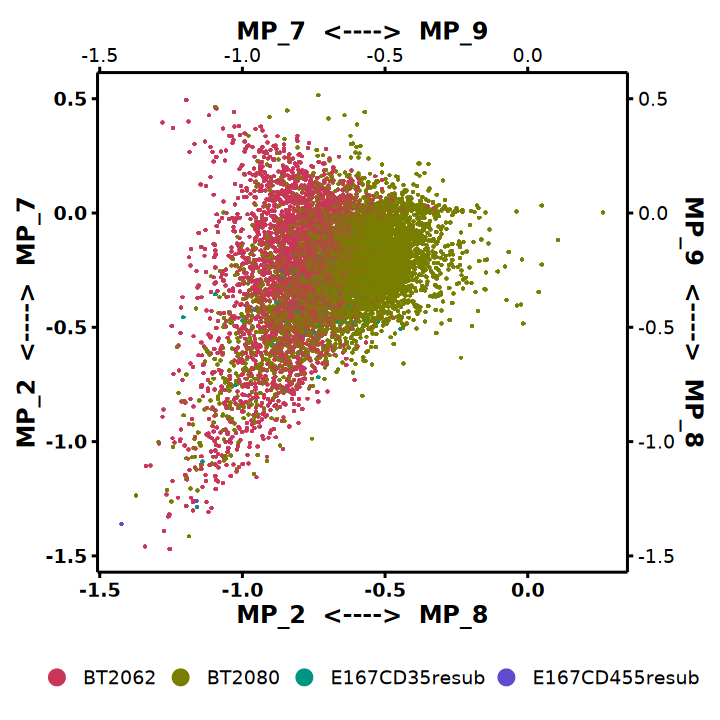

In [16]:
options(repr.plot.height = 6, repr.plot.width = 6)
do_CellularStatesPlot(sample = labelle,
                      # group.by = 'leiden_1_3',
                      pt.size = 5,
                      plot_cell_borders = FALSE,
                      raster = TRUE,
                      # plot_marginal_distributions = TRUE,
                                   input_gene_list = as.list(as.data.frame(MP_list)),
                                   x1 = "MP_7",
                                   y1 = "MP_2",
                                   x2 = "MP_9",
                                   y2 = "MP_8",
                                   enforce_symmetry = FALSE)

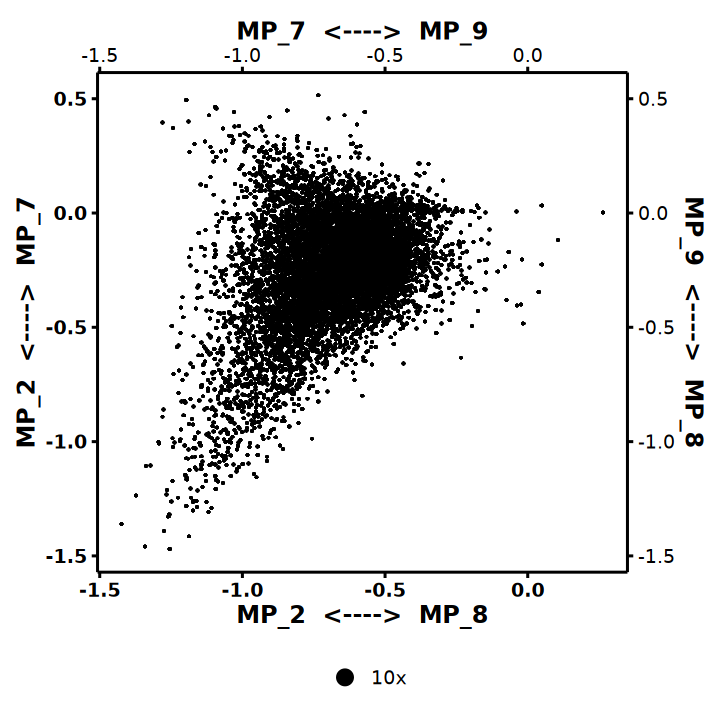

In [17]:
labelle$tech <- '10x'
do_CellularStatesPlot(sample = labelle,
                      colors.use = c('10x'= 'black'),
                      group.by = 'tech',
                      pt.size = 5,
                      plot_cell_borders = FALSE,
                      raster = TRUE,
                      # plot_marginal_distributions = TRUE,
                                   input_gene_list = as.list(as.data.frame(MP_list)),
                                   x1 = "MP_7",
                                   y1 = "MP_2",
                                   x2 = "MP_9",
                                   y2 = "MP_8",
                                   enforce_symmetry = FALSE)

In [18]:
ggsave('figures/state_plot_myeloid_cells_labelle10x.pdf')

Saving 6.67 x 6.67 in image


In [19]:
for (i in 1:ncol(MP_list)) {
  gene_set <- as.data.frame(MP_list)[[i]]
  labelle <- AddModuleScore(
    object = labelle,
    features = list(gene_set),
    name = paste0(colnames(MP_list)[i], '_')
  )
}

Warning message:
“The following features are not present in the object: ATP5F1E, RACK1, not searching for symbol synonyms”
Warning message:
“The following features are not present in the object: C12ORF57, not searching for symbol synonyms”
Warning message:
“The following features are not present in the object: SELENOP, MS4A4E, not searching for symbol synonyms”
Warning message:
“The following features are not present in the object: MTRNR2L12, not searching for symbol synonyms”


In [20]:
# Extracting the scores
scores <- FetchData(
  labelle,
  vars = c('MP_2_1', 'MP_7_1','MP_8_1','MP_9_1')
)

colnames(scores) <- sub("_1$", "", colnames(scores))
colnames(scores) <- sub("_", "", colnames(scores))

scores

,MP2,MP7,MP8,MP9
,<dbl>,<dbl>,<dbl>,<dbl>
E167CD35resub_ACATACGTCGTAGGAG_1,1.1986590,-0.088586777,-0.03260050,-0.13684229
E167CD35resub_ACCCACTGTGCCTGGT_1,0.5574595,0.196743465,-0.04895894,-0.24825862
E167CD35resub_ACGAGGAAGTTTCCTT_1,0.6739291,0.134831229,-0.04937072,-0.04456316
E167CD35resub_ACGCCAGAGGGATCTG_1,0.6548301,0.256928769,-0.18133676,-0.04652024
E167CD35resub_ACGGAGAAGCCCAATT_1,0.6040094,0.257729704,0.08490536,0.06673437
E167CD35resub_ACTGATGTCGGAGGTA_1,0.6801189,-0.039565966,0.01850850,-0.29678800
E167CD35resub_AGAGTGGCATTCTTAC_1,0.7828165,0.306276943,-0.01589989,-0.02694567
E167CD35resub_AGATTGCTCGAATGGG_1,0.6155702,0.363604097,-0.20262818,-0.06752419
E167CD35resub_AGCCTAATCTGATTCT_1,0.5960621,0.328796002,-0.13571531,-0.17401185


In [21]:
# as suggested in https://doi.org/10.1038/s41588-023-01570-0
# Normalize scores by subtracting the mean score for each MP
normalized_scores <- apply(scores, 2, function(x) x - mean(x))
                           
# Function to determine the assignment of each cell
assign_to_MP <- function(score_row) {
  sorted_scores <- sort(score_row, decreasing = TRUE)
  top_score <- sorted_scores[1]
  second_score <- sorted_scores[2]

  if (second_score <= 0.95 * top_score) {
    return(names(sorted_scores)[1])
  } else {
    return("unresolved")
  }
}

# Apply the function to each row (cell)
cell_assignments <- apply(normalized_scores, 1, assign_to_MP)

In [22]:
labelle$MP_Assignment <- cell_assignments

Warning message:
“Scaling data with a low number of groups may produce misleading results”
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


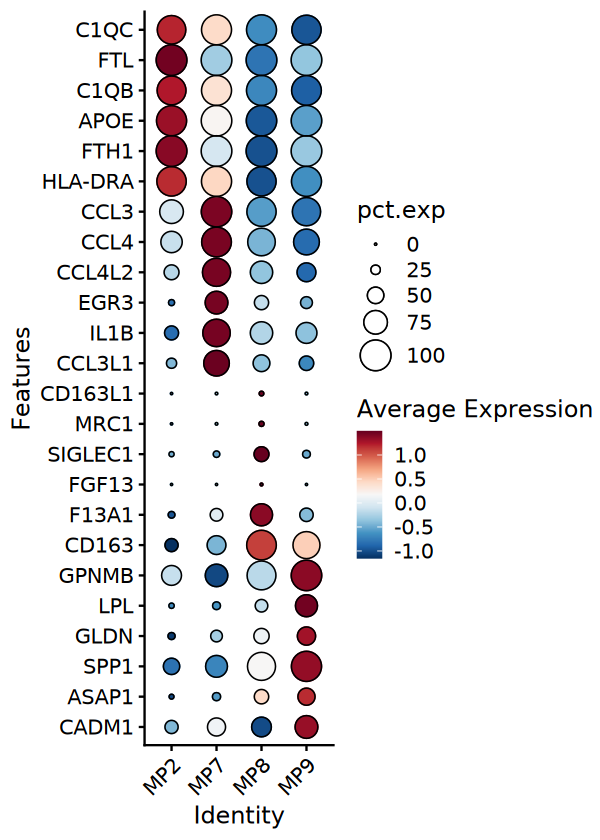

In [23]:
labelle$MP_Assignment <- factor(labelle$MP_Assignment,
                             levels=c('MP2', 'MP7',
                                          'MP8','MP9','unresolved'))
options(repr.plot.height = 7, repr.plot.width = 5)
DotPlot(subset(labelle, MP_Assignment!='unresolved'),dot.scale = 8,
        features = rev(c('C1QC','FTL','C1QB', 'APOE','FTH1','HLA-DRA',
                                     'CCL3', 'CCL4', 'CCL4L2','EGR3','IL1B', 'CCL3L1',
                                     'CD163L1', 'MRC1', 'SIGLEC1', 'FGF13','F13A1', 'CD163',
                                     'GPNMB', 'LPL', 'GLDN', 'SPP1','ASAP1','CADM1')), 
        group.by = 'MP_Assignment', assay = 'RNA') +
  geom_point(aes(size=pct.exp), shape = 21, colour="black", stroke=0.5) +
  scale_color_gradientn(colors =rev(RColorBrewer::brewer.pal(11, "RdBu"))) + 
  guides(size=guide_legend(override.aes=list(shape=21, colour="black", fill="white")))+
  theme(axis.text.x = element_text(angle = 45, hjust = 1))+coord_flip()

In [24]:
ggsave('figures/dotplot_MP_genes_labelle10x.pdf', width = 4.5)

Saving 4.5 x 6.67 in image
